In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense, Dropout,LSTM
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv('AMZN.csv')


In [3]:
df.head(2)

,Price,Adj Close,Close,High,Low,Open,Volume
0,Ticker,AMZN,AMZN,AMZN,AMZN,AMZN,AMZN
1,2015-01-02,15.425999641418457,15.425999641418457,15.737500190734863,15.347999572753906,15.628999710083008,55664000


In [4]:
df.rename(columns={'Price':'Date'},inplace=True)

In [5]:
df.dtypes

Date         object
Adj Close    object
Close        object
High         object
Low          object
Open         object
Volume       object
dtype: object

In [6]:
numeric_columns = df.columns.difference(['Date'])
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric,errors = 'coerce')

In [7]:
df.dtypes

Date          object
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume       float64
dtype: object

In [9]:
df.head(2)

,Date,Adj Close,Close,High,Low,Open,Volume
0,Ticker,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-01-02,15.426,15.426,15.7375,15.348,15.629,55664000.0


In [10]:
df.drop(df.index[0],inplace=True)

In [11]:
df.head(2)

,Date,Adj Close,Close,High,Low,Open,Volume
1,2015-01-02,15.4260,15.4260,15.7375,15.3480,15.6290,55664000.0
2,2015-01-05,15.1095,15.1095,15.4190,15.0425,15.3505,55484000.0


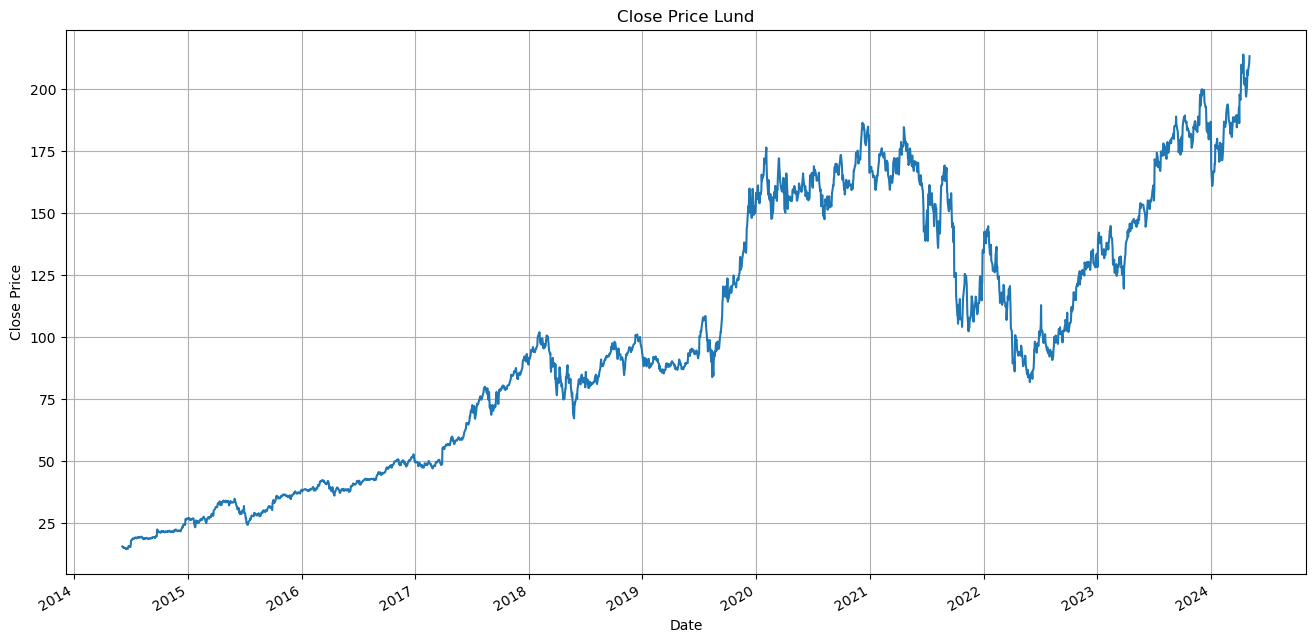

In [20]:
df['Date'] = pd.to_datetime(df['Date'])
plt.figure(figsize=(16,8))
plt.plot(df['Date'],df['Close'])
plt.title('Close Price Lund')
plt.xticks(rotation = 30)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=12))
plt.gcf().autofmt_xdate()
plt.grid()
plt.show()

In [17]:
df.head(-10)

,Date,Adj Close,Close,High,Low,Open,Volume
1,2015-01-02,15.426000,15.426000,15.737500,15.348000,15.629000,55664000.0
2,2015-01-05,15.109500,15.109500,15.419000,15.042500,15.350500,55484000.0
3,2015-01-06,14.764500,14.764500,15.150000,14.619000,15.112000,70380000.0
4,2015-01-07,14.921000,14.921000,15.064000,14.766500,14.875000,52806000.0
5,2015-01-08,15.023000,15.023000,15.157000,14.805500,15.016000,61768000.0
...,...,...,...,...,...,...,...
2483,2024-11-12,208.910004,208.910004,209.539993,206.009995,208.369995,38942900.0
2484,2024-11-13,214.100006,214.100006,215.089996,209.139999,209.399994,46212900.0
2485,2024-11-14,211.479996,211.479996,215.899994,210.880005,214.160004,42620300.0
2486,2024-11-15,202.610001,202.610001,207.339996,199.610001,206.759995,86591100.0


In [21]:
df.shape

(2497, 7)

In [22]:
import math

In [23]:
df1 = df.filter(['Close'])
df2 = df1.values
training_data_len = math.ceil(len(df2) * .8)

In [24]:
training_data_len

1998

In [25]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df2)

In [27]:
scaled_data

array([[0.00539918],
       [0.00381472],
       [0.00208758],
       ...,
       [0.9689115 ],
       [0.983029  ],
       [0.99669589]])

In [29]:
train_data = scaled_data[0:training_data_len,:]
X_train = []
y_train = []

for i in range(60,len(train_data)):
    X_train.append(train_data[i-60:i,0])
    y_train.append(train_data[i,0])
    if i<=61:
        print(X_train)
        print(y_train)
        print()

[array([0.00539918, 0.00381472, 0.00208758, 0.00287105, 0.00338168,
       0.00249809, 0.00111638, 0.00194992, 0.00158196, 0.        ,
       0.00094867, 0.00062327, 0.00257819, 0.00584974, 0.00636788,
       0.00568453, 0.00495613, 0.00424526, 0.00621519, 0.01691593,
       0.01940401, 0.01917373, 0.0194741 , 0.02176193, 0.02185955,
       0.0209284 , 0.02153915, 0.02207482, 0.02258294, 0.02374939,
       0.02214741, 0.02163177, 0.02304102, 0.02420746, 0.02332637,
       0.02293839, 0.02463548, 0.02449281, 0.02333137, 0.02470808,
       0.02444525, 0.02397216, 0.02525125, 0.02331385, 0.02293087,
       0.02066557, 0.0198796 , 0.02184954, 0.0209334 , 0.02162676,
       0.02126882, 0.02207482, 0.02159923, 0.02291335, 0.02206731,
       0.02181199, 0.02102852, 0.02012491, 0.0209284 , 0.02193715])]
[0.021313873726148208]

[array([0.00539918, 0.00381472, 0.00208758, 0.00287105, 0.00338168,
       0.00249809, 0.00111638, 0.00194992, 0.00158196, 0.        ,
       0.00094867, 0.00062327, 0.0

In [30]:
X_train,y_train = np.array(X_train),np.array(y_train)


In [31]:
print(X_train.shape)
print(y_train.shape)

(1938, 60)
(1938,)


In [34]:
X_train = np.reshape(X_train,(X_train.shape[0],X_train.shape[1],1))
X_train.shape

(1938, 60, 1)

In [35]:
model = Sequential()
model.add(LSTM(50,return_sequences=True,input_shape = (X_train.shape[1],1)))
model.add(LSTM(50,return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))


/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.compile(optimizer='adam',loss = 'mean_squared_error')

In [39]:
model.fit(X_train,y_train,batch_size=1,epochs=5)

Epoch 1/5
1938/1938 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 7.6731e-04
Epoch 2/5
1938/1938 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 5.9859e-04
Epoch 3/5
1938/1938 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 3.8579e-04
Epoch 4/5
1938/1938 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 3.7810e-04
Epoch 5/5
1938/1938 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 2.8461e-04


In [40]:
test_data = scaled_data[training_data_len-60:,:]
X_test = []
y_test = df2[training_data_len:,:]
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60,0])
    print(X_test)

[0.5717200016400606]
[0.5717200016400606, 0.5603559175792051]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757, 0.5398805983226505]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757, 0.5398805983226505, 0.5216079788982954]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757, 0.5398805983226505, 0.5216079788982954, 0.5154503422308656]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757, 0.5398805983226505, 0.5216079788982954, 0.5154503422308656, 0.49777847995760294]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757, 0.5398805983226505, 0.5216079788982954, 0.5154503422308656, 0.49777847995760294, 0.5046369808708558]
[0.5717200016400606, 0.5603559175792051, 0.5465888813024526, 0.552245906107757, 0.5398805983226

In [42]:
X_test = np.array(X_test)

In [43]:
X_test.shape

(499,)

In [51]:
X_test = np.reshape(X_test,(X_test.shape[0],X_test.shape[1],1))

In [52]:
X_test.shape

(499, 1, 1)

In [53]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 422us/step


In [54]:
rmse = np.sqrt(np.mean(predictions - y_test)**2)
rmse

22.427053463005112

/var/folders/89/hlf99zq566v5gtf30kyt2gp40000gn/T/ipykernel_22355/3718196878.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = predictions


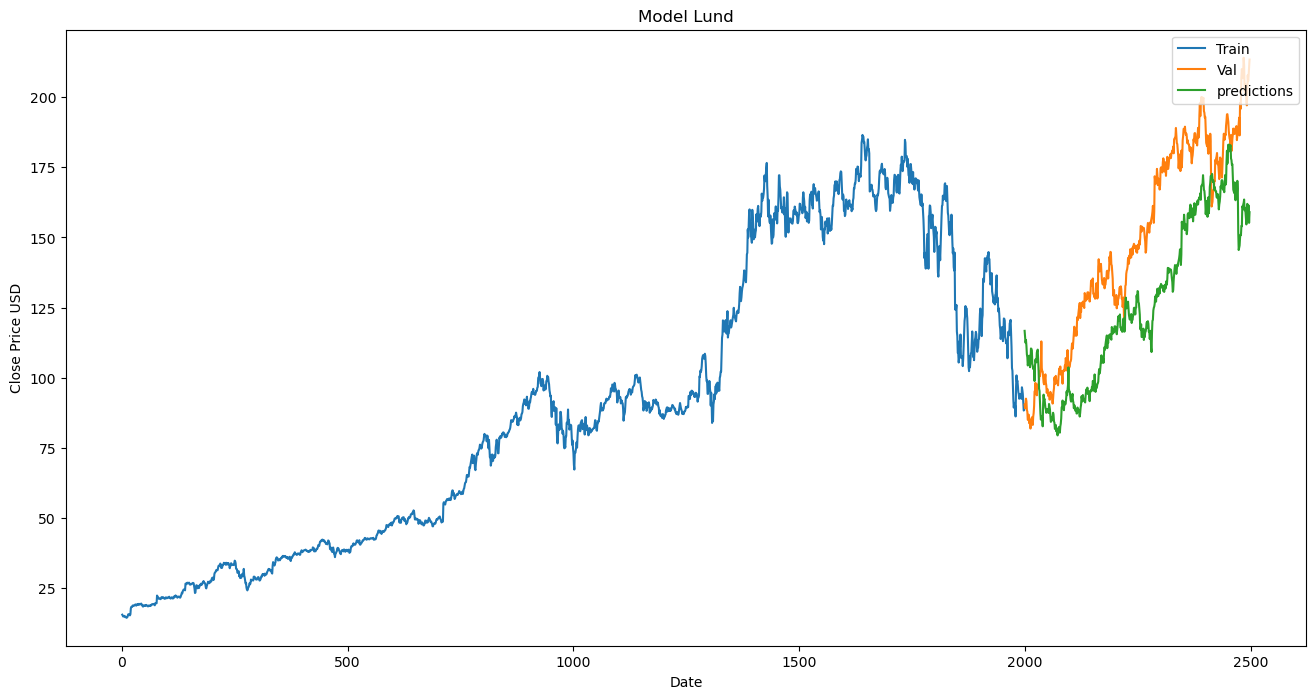

In [57]:
train = df1[:training_data_len]
valid = df1[training_data_len:]
valid['predictions'] = predictions


plt.figure(figsize=(16,8))
plt.title('Model Lund')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.plot(train['Close'])
plt.plot(valid[['Close','predictions']])
plt.legend(['Train','Val','predictions'],loc = 'upper right')
plt.show()

In [58]:
valid

,Close,predictions
1999,90.349998,116.673157
2000,89.089996,114.745720
2001,90.550003,112.426468
2002,92.489998,113.377380
2003,91.580002,111.302620
...,...,...
2493,207.860001,159.816574
2494,205.740005,157.035370
2495,207.889999,161.386261
2496,210.710007,155.197311
